In [1]:
import _plotting as plot
import jax
import jax.numpy as jnp

from xxm.core.align import match_states_by_conditional_mean as match_states
from xxm.hmm import GaussianARHMM

In [2]:
def make_true_model() -> GaussianARHMM:
    return GaussianARHMM.from_params(
        initial_probs=jnp.array([0.4, 0.3, 0.3]),
        transition_probs=jnp.array(
            [
                [0.97, 0.02, 0.01],
                [0.02, 0.97, 0.01],
                [0.02, 0.02, 0.96],
            ]
        ),
        emission_coefficients=jnp.array(
            [
                # clockwise rotation
                [
                    [[0.92, 0.32]],
                    [[-0.32, 0.92]],
                ],
                # counter-clockwise rotation
                [
                    [[0.92, -0.32]],
                    [[0.32, 0.92]],
                ],
                # anisotropic dynamics
                [
                    [[0.97, 0.00]],
                    [[0.00, 0.65]],
                ],
            ]
        ),  # (K=3, O=2, L=1, I=2)
        emission_bias=jnp.zeros((3, 2)),
        emission_covariances=jnp.array(
            [
                [[0.05, 0.00], [0.00, 0.05]],
                [[0.05, 0.00], [0.00, 0.05]],
                [[0.05, 0.00], [0.00, 0.05]],
            ]
        ),
    )


true_model = make_true_model()

true_states, observations = true_model.sample(
    num_steps=1000,
    key=jax.random.key(0),
)

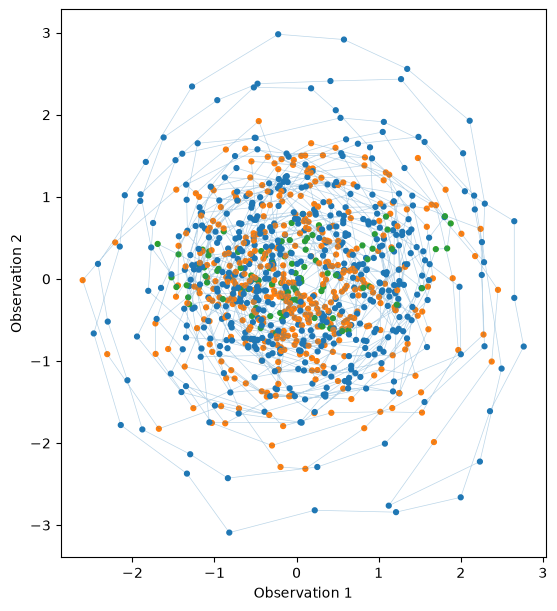

In [3]:
plot.plot_sequence_2d(observations, true_states)

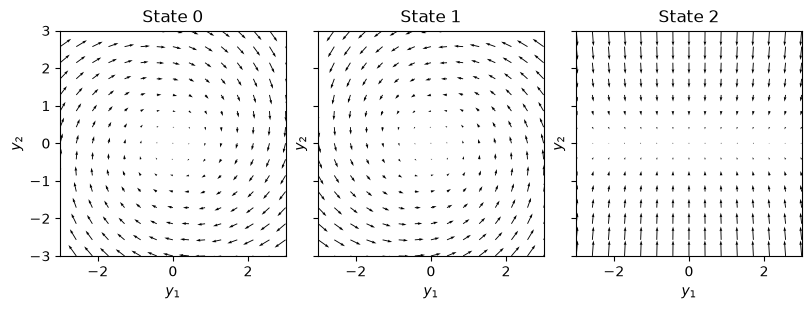

In [4]:
plot.plot_conditional_linear_dynamics(
    true_model.states,
)

In [5]:
posterior, _ = true_model.infer(observations)

In [6]:
observations

Array([[-0.29865482, -0.07883549],
       [-0.12491518, -0.15404667],
       [-0.09174964, -0.3591767 ],
       ...,
       [ 0.92623633,  0.3678652 ],
       [ 1.1077571 ,  0.6010183 ],
       [ 1.1621464 ,  0.36372834]], dtype=float32)

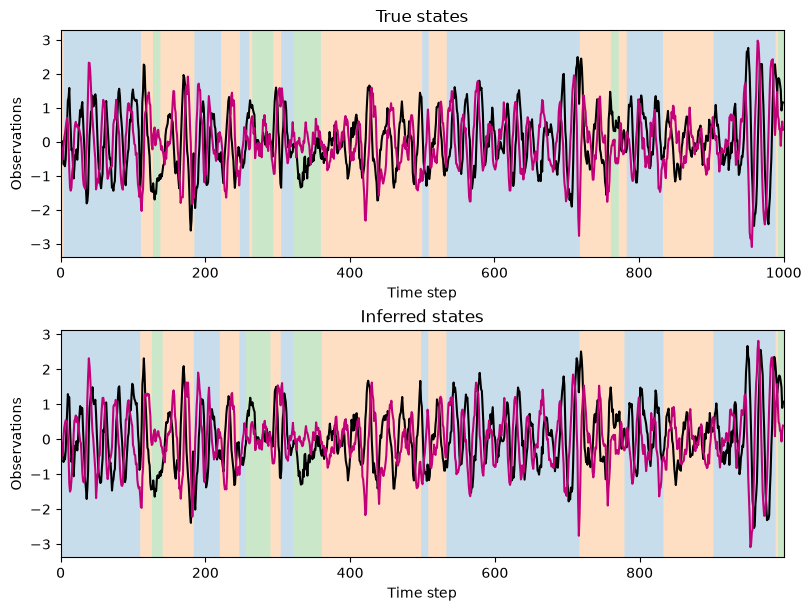

In [7]:
plot.plot_inferred_states_comparison(
    true_states=true_states,
    observations=observations,
    inferred_states=true_model.most_likely_states(posterior),
    reconstruction=true_model.observation_mean(observations, posterior),
)

EM:   0%|          | 0/50 [00:00<?, ?it/s]

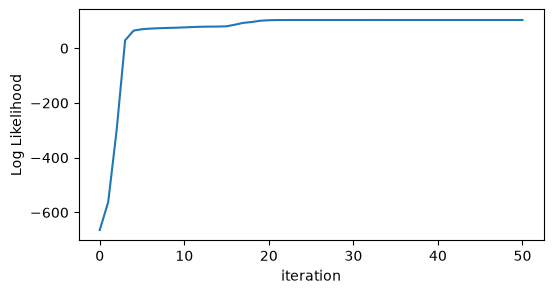

In [8]:
initial_model = GaussianARHMM.from_kmeans(
    key=jax.random.key(0),
    observations=observations,
    num_states=true_model.num_states,
    num_lags=1,
)


learned_model, log_likelihoods = initial_model.fit(
    observations=observations,
    num_iters=50,
)


plot.plot_fit_progress(log_likelihoods, name='Log Likelihood')

In [9]:
permutation = match_states(
    learned_model.states_conditional(observations).mean,
    true_model.states_conditional(observations).mean,
)

matched_model = learned_model.permute(permutation)

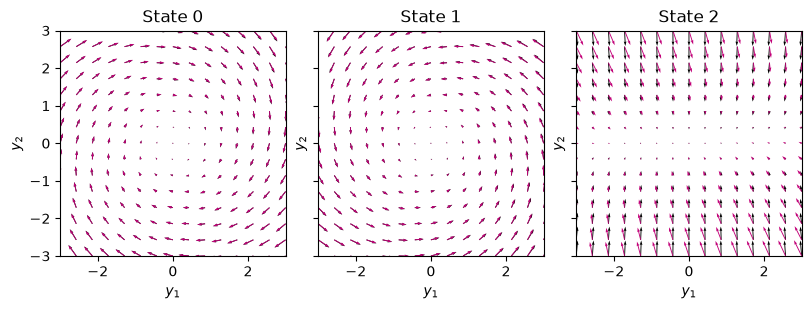

In [10]:
plot.plot_conditional_linear_dynamics_comparison(
    true_model.states, matched_model.states
)

In [11]:
posterior, _ = matched_model.infer(observations)

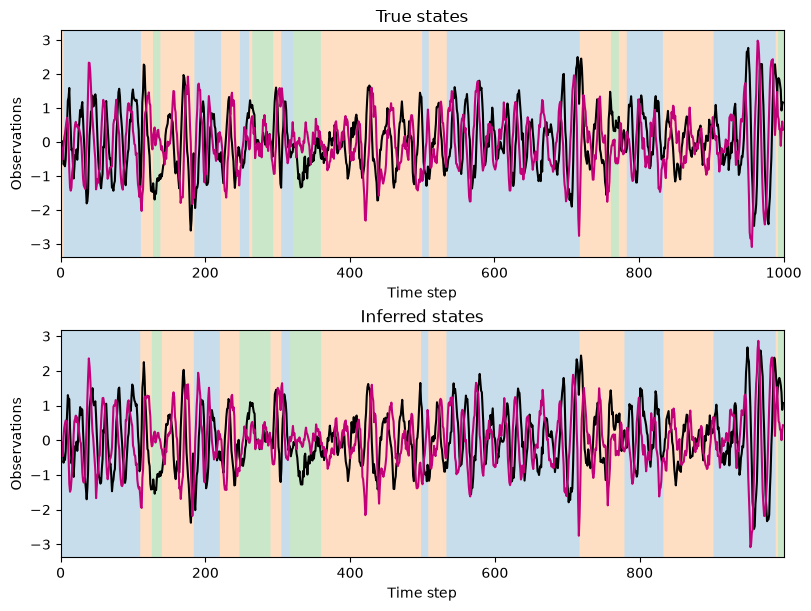

In [12]:
plot.plot_inferred_states_comparison(
    observations=observations,
    true_states=true_states,
    inferred_states=matched_model.most_likely_states(posterior),
    reconstruction=matched_model.observation_mean(observations, posterior),
)